In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['nordbruecke'].sum())
header = 'nordbruecke'

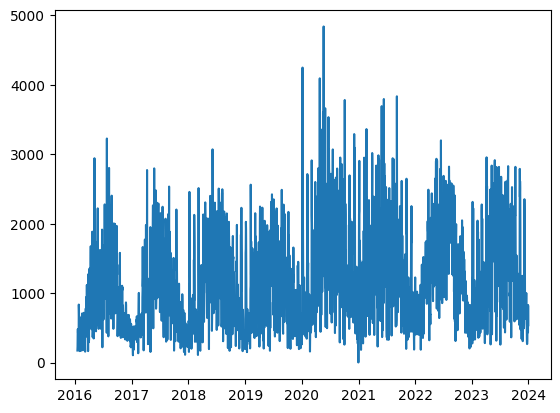

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

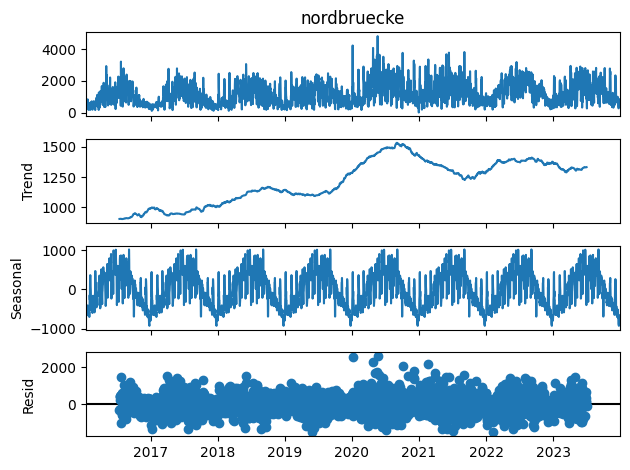

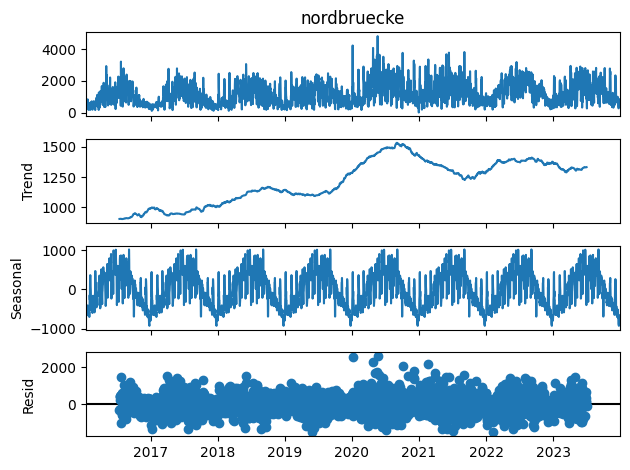

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.9221
p-value = 0.0019


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -7.6327
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


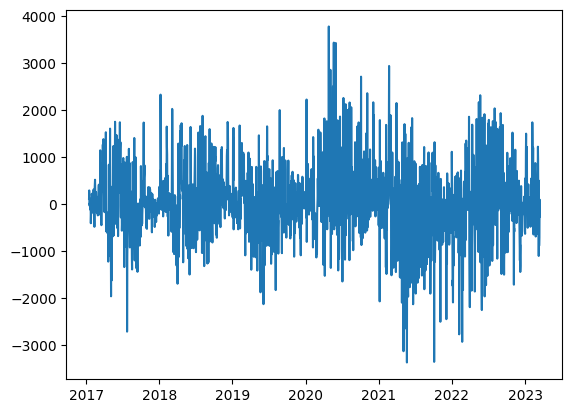

In [10]:
plt.plot(df_train.loc[:,'differences'] )

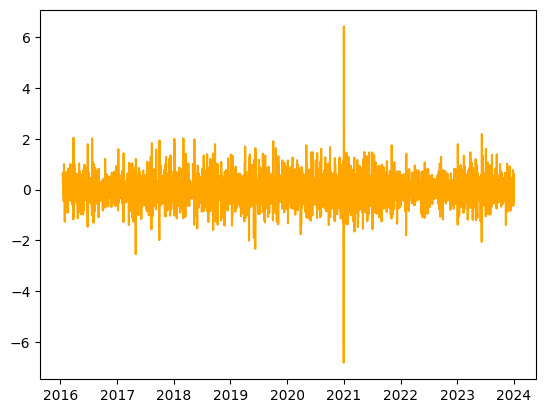

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -20.2572
P-value = 0.0000


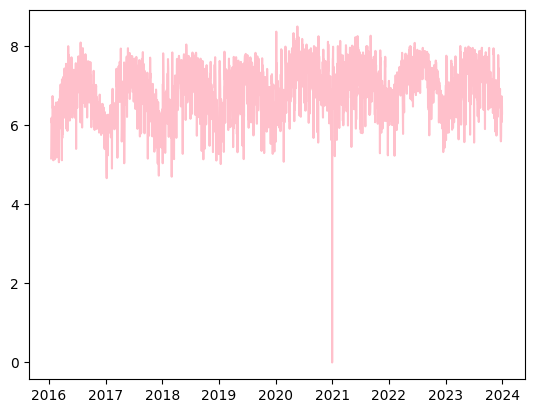

In [13]:
plt.plot(df['log'], color='pink')

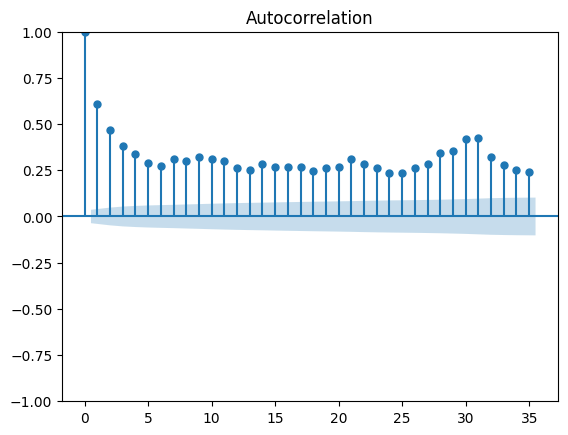

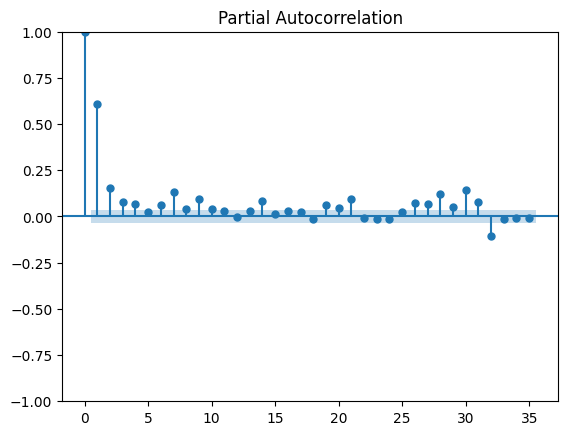

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 3):
        p, d, q = i, 0, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -2220.5275, AIC: 4445.0550


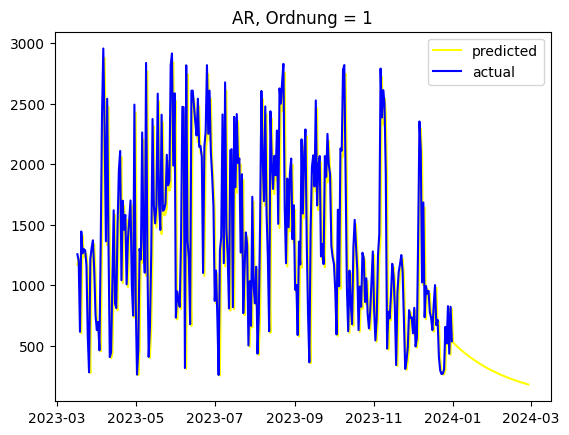

mean absolute error (mae): ARIMA: 1403.7658, simple: 491.3828
mean squared error (mse): ARIMA: 2451158.7651, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4286, simple: 0.4397
Log Likelihood: -2078.2815, AIC: 4162.5631


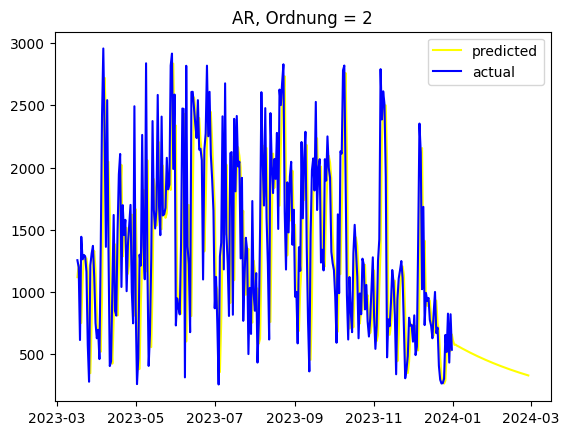

mean absolute error (mae): ARIMA: 1403.7579, simple: 491.3828
mean squared error (mse): ARIMA: 2451173.4074, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4303, simple: 0.4397
Log Likelihood: -2031.7421, AIC: 4071.4842


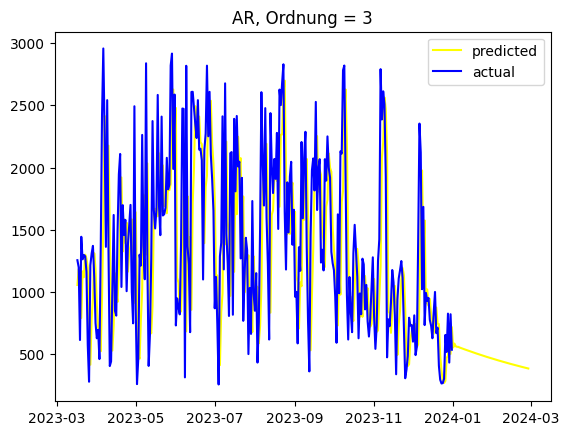

mean absolute error (mae): ARIMA: 1403.7546, simple: 491.3828
mean squared error (mse): ARIMA: 2451195.3291, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4335, simple: 0.4397
Log Likelihood: -1996.8328, AIC: 4003.6656


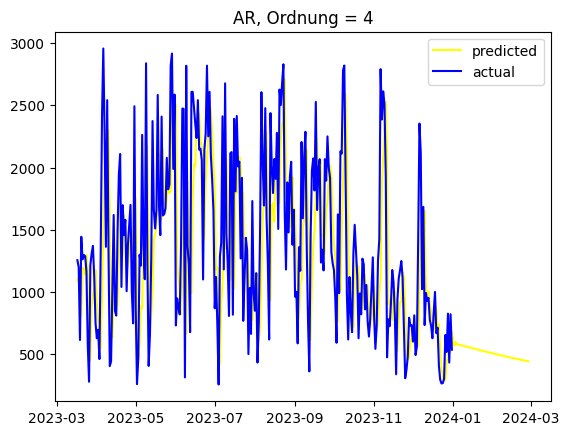

mean absolute error (mae): ARIMA: 1403.7522, simple: 491.3828
mean squared error (mse): ARIMA: 2451202.1880, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4299, simple: 0.4397


In [17]:
for i in range(1, 5):
    p, d, q = i, 0, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,nordbruecke,scaled,log,differences,predicted_mean,crossings
2016-01-16,173.000000,173.0,5.153292,NaN,NaN,NaN
2016-01-17,230.000000,230.0,5.438079,NaN,NaN,NaN
2016-01-18,442.000000,442.0,6.091310,NaN,NaN,NaN
2016-01-19,483.000000,483.0,6.180017,NaN,NaN,NaN
2016-01-20,425.000000,425.0,6.052089,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,452.751098,NaN,NaN,NaN,6.115343,452.751098
2024-02-25,450.563543,NaN,NaN,NaN,6.110499,450.563543
2024-02-26,448.388277,NaN,NaN,NaN,6.105660,448.388277
2024-02-27,446.225224,NaN,NaN,NaN,6.100824,446.225224


Log Likelihood: -2220.5275, AIC: 4445.0550


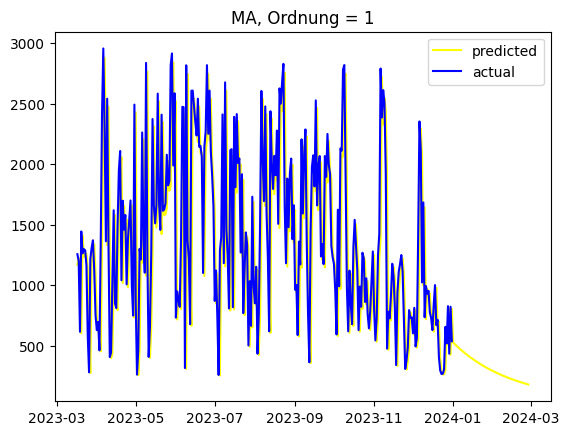

mean absolute error (mae): ARIMA: 1403.7658, simple: 491.3828
mean squared error (mse): ARIMA: 2451158.7651, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4286, simple: 0.4397
Log Likelihood: -2078.2815, AIC: 4162.5631


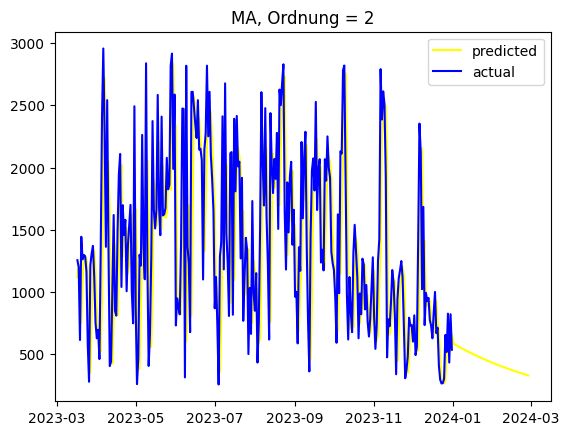

mean absolute error (mae): ARIMA: 1403.7579, simple: 491.3828
mean squared error (mse): ARIMA: 2451173.4074, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4303, simple: 0.4397


In [19]:
ma_arima()

Seasonal ARIMA

In [20]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,7202,13499,17428,29206,38461,31439,43228,45656,43369,23146,17800,14948
2017,11918,14926,30316,28959,41552,45223,42135,39556,29934,27081,19294,12273
2018,21475,20893,26428,41302,44358,44786,50619,43123,36797,32620,27108,23317
2019,21958,31395,29185,35750,39007,46275,42340,41158,33922,32580,26063,22306
2020,31088,27278,43270,52610,62664,54913,58842,52708,52154,38568,36435,34099
2021,30844,41284,39711,43698,43093,50822,43472,46217,47328,34281,28092,27084
2022,23130,22994,45933,39326,57244,53834,56682,67075,44486,40505,32981,17477
2023,27292,29749,36320,42386,51595,56136,43951,54822,47733,37989,33022,25363


In [21]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,nordbruecke,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean
2016-01-16,173,173.0,5.153292,NaN,NaN,01-16,6.387491,-1.234199
2016-01-17,230,230.0,5.438079,0.284788,NaN,01-17,6.183980,-0.745901
2016-01-18,442,442.0,6.091310,0.653231,NaN,01-18,6.386701,-0.295391
2016-01-19,483,483.0,6.180017,0.088707,NaN,01-19,6.282959,-0.102942
2016-01-20,425,425.0,6.052089,-0.127927,NaN,01-20,6.293187,-0.241098
...,...,...,...,...,...,...,...,...
2023-12-27,519,519.0,6.251904,-0.234257,NaN,12-27,6.172962,0.078942
2023-12-28,827,827.0,6.717805,0.465901,NaN,12-28,6.242056,0.475748
2023-12-29,434,434.0,6.073045,-0.644760,NaN,12-29,6.147379,-0.074334
2023-12-30,822,822.0,6.711740,0.638696,NaN,12-30,6.276366,0.435374


In [22]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    1194.033735
1    1261.337349
2    1273.380723
3    1212.260241
4    1145.604819
5    1050.456731
6    1271.533654
Name: nordbruecke, dtype: float64


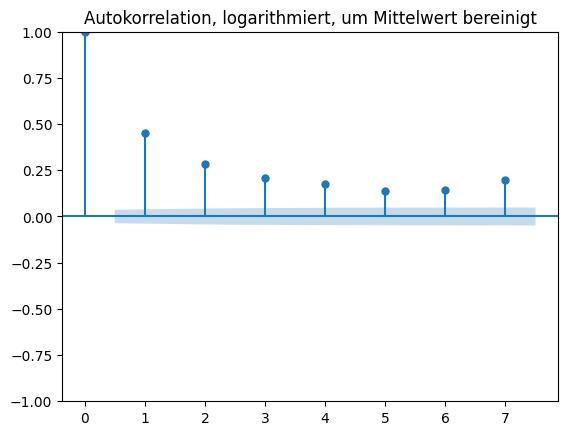

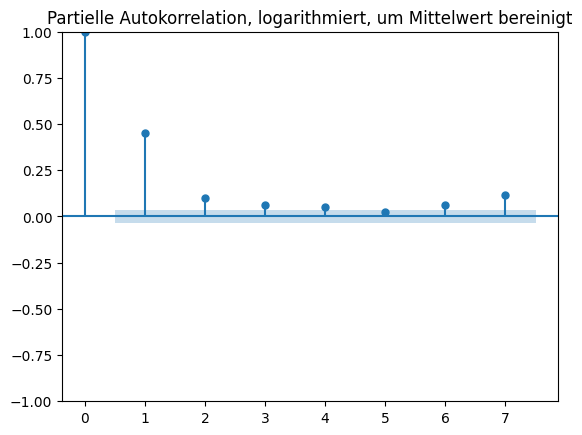

In [23]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

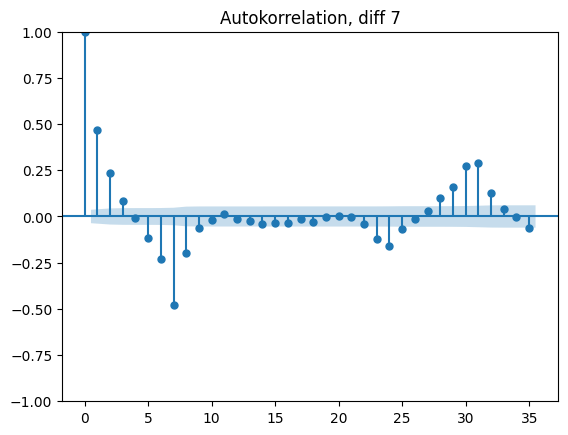

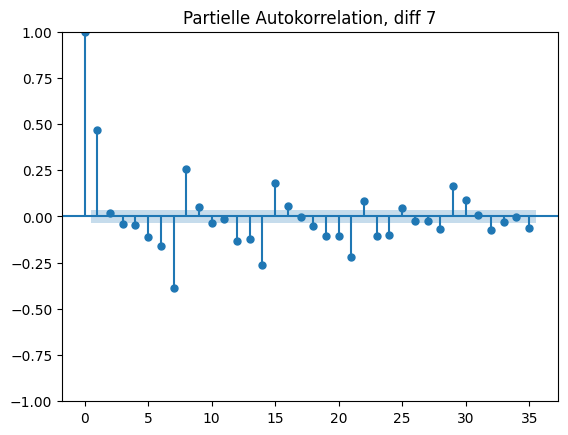

In [24]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [25]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

ARIMA (0,0,0)x(0,1,0,7) LL -2621.8012, AIC: 5245.6024
ARIMA (0,1,0)x(0,1,0,7) LL -2747.5602, AIC: 5497.1205
ARIMA (1,0,0)x(0,1,1,7) LL -1723.1025, AIC: 3452.2050
ARIMA (1,0,0)x(0,1,2,7) LL -1723.0830, AIC: 3454.1660
ARIMA (1,1,0)x(0,1,2,7) LL -1870.9497, AIC: 3749.8993
ARIMA (0,0,1)x(0,1,2,7) LL -1817.1609, AIC: 3642.3217
ARIMA (0,1,1)x(0,1,2,7) LL -1781.3534, AIC: 3570.7068
ARIMA (0,1,1)x(2,1,0,7) LL -2056.6019, AIC: 4121.2037


In [26]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -1723.083
Date:                                Sun, 09 Feb 2025   AIC                           3454.166
Time:                                        22:44:59   BIC                           3477.162
Sample:                                    01-16-2016   HQIC                          3462.546
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5228      0.011     49.508      0.000       0.502       0.543
ma.

In [27]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-12-31')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean     unlogged  new_predict
2022-05-30        6.762543   864.838792   864.838792
2022-05-31        7.005829  1103.043769  1103.043769
2022-06-01        7.308126  1492.377288  1492.377288
2022-06-02        7.153066  1278.018360  1278.018360
2022-06-03        6.997963  1094.401164  1094.401164
...                    ...          ...          ...
2024-12-27        7.022909  1122.046031  1122.046031
2024-12-28        7.070013  1176.163808  1176.163808
2024-12-29        7.231010  1381.617697  1381.617697
2024-12-30        7.087323  1196.699696  1196.699696
2024-12-31        7.176212  1307.944295  1307.944295

[947 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

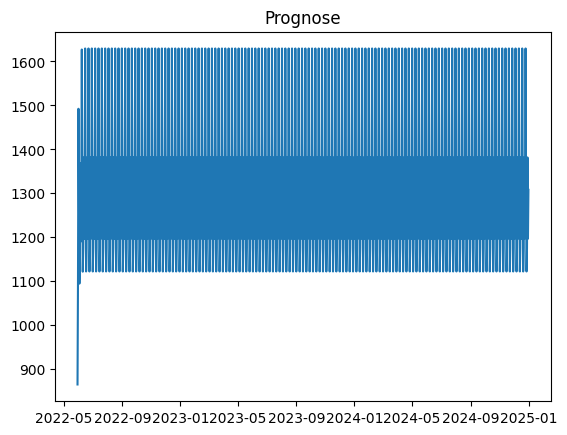

In [28]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

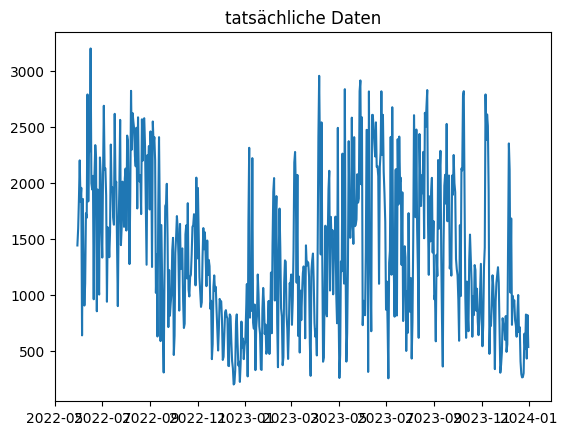

In [29]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

,predicted_mean,unlogged,final_data
2022-05-30,6.762543,864.838792,864.838792
2022-05-31,7.005829,1103.043769,1103.043769
2022-06-01,7.308126,1492.377288,1492.377288
2022-06-02,7.153066,1278.018360,1278.018360
2022-06-03,6.997963,1094.401164,1094.401164
...,...,...,...
2024-12-27,7.022909,1122.046031,1122.046031
2024-12-28,7.070013,1176.163808,1176.163808
2024-12-29,7.231010,1381.617697,1381.617697
2024-12-30,7.087323,1196.699696,1196.699696


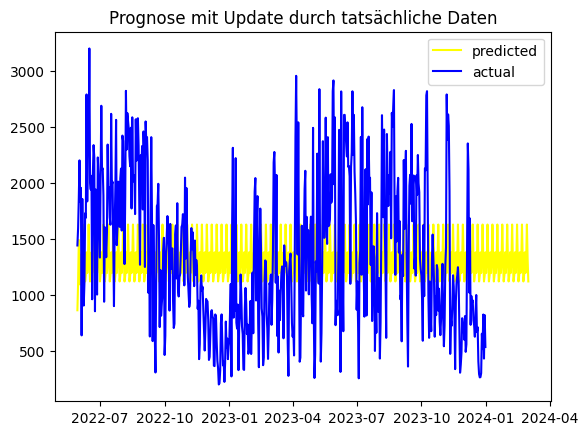

In [31]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [32]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 567.3969
mean squared error (mse): ARIMA: 461398.3339
mean absolute percentage error (mape): ARIMA: 0.5973


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\1728239483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\1728239483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_1

Monatlich


In [33]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     21863.375
2     25252.250
3     33573.875
4     39154.625
5     47246.750
6     47928.500
7     47658.625
8     48789.375
9     41965.375
10    33346.250
11    27599.375
12    22108.375
Name: nordbruecke, dtype: float64


In [34]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [35]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [36]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,nordbruecke
year-month,,
2016-01-01,2016-01-01,7202
2016-02-01,2016-02-01,13499
2016-03-01,2016-03-01,17428
2016-04-01,2016-04-01,29206
2016-05-01,2016-05-01,38461
...,...,...
2023-08-01,2023-08-01,54822
2023-09-01,2023-09-01,47733
2023-10-01,2023-10-01,37989


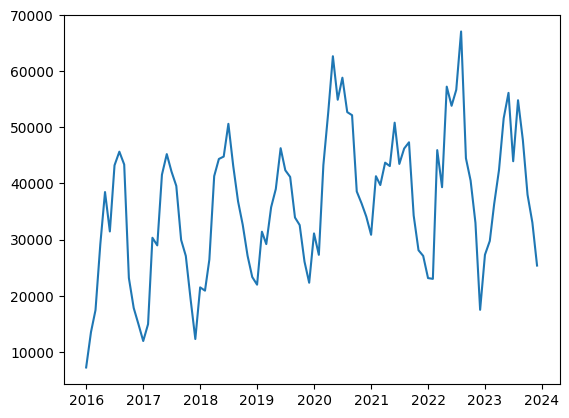

In [37]:
plt.plot(df_month[header])

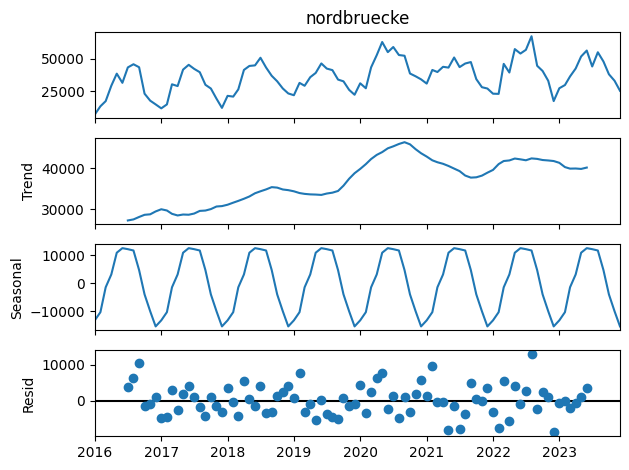

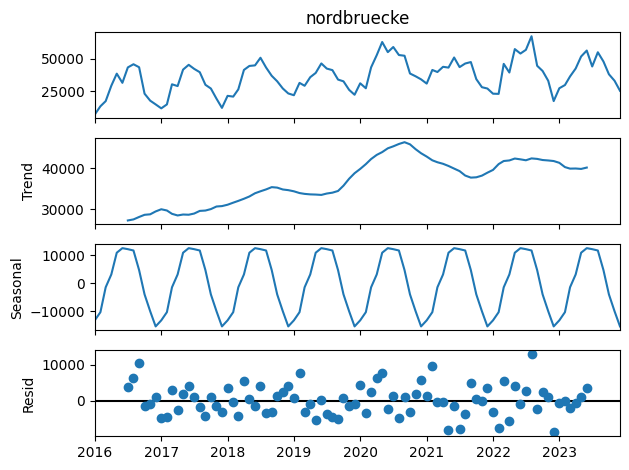

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [39]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -1.8672
p-value = 0.3476


In [40]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,nordbruecke,scaled,log
year-month,,,,
2016-01-01,2016-01-01,7202,1.000000,0.000000
2016-02-01,2016-02-01,13499,7055.348003,8.861541
2016-03-01,2016-03-01,17428,11456.893708,9.346347
2016-04-01,2016-04-01,29206,24651.448382,10.112591
2016-05-01,2016-05-01,38461,35019.558716,10.463662
...,...,...,...,...
2023-08-01,2023-08-01,54822,53348.316487,10.884598
2023-09-01,2023-09-01,47733,45406.713661,10.723415
2023-10-01,2023-10-01,37989,34490.790690,10.448448


In [41]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [42]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -3.1791
P-value = 0.0212


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


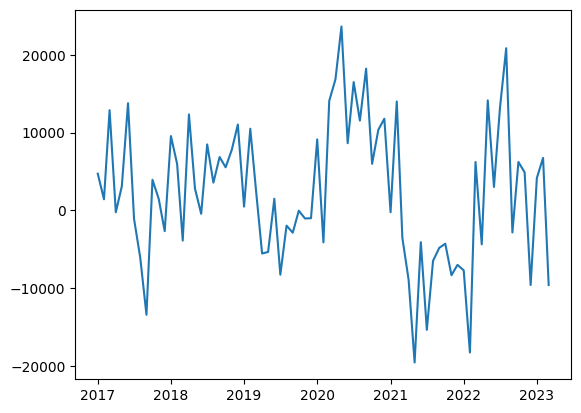

In [43]:
plt.plot(df_train['differences'])

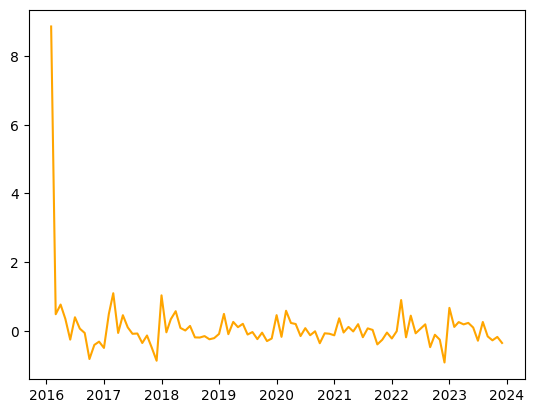

In [44]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [45]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -3.7688
P-value = 0.0032


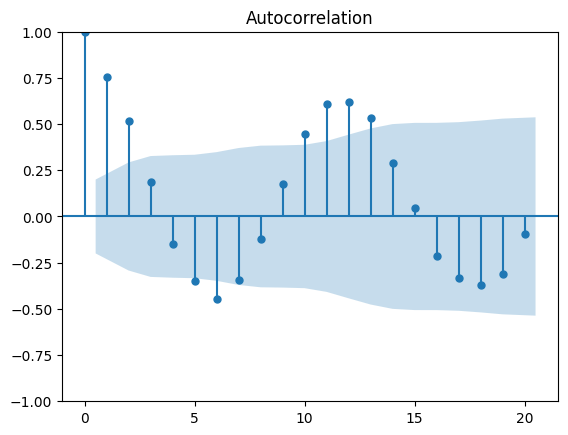

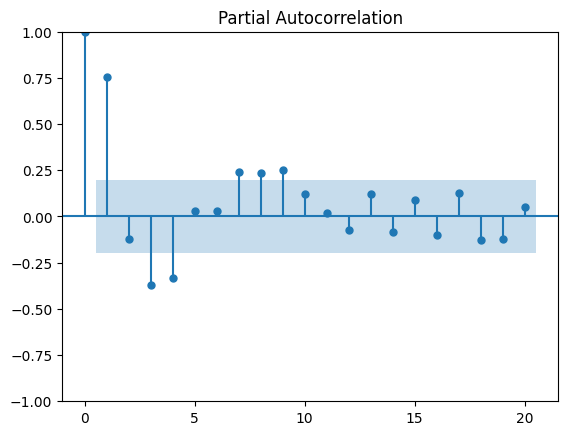

In [46]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [47]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,nordbruecke,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,7202,1.000000,0.000000,NaN,1,8.519421,-8.519421
2016-02-01,2016-02-01,13499,7055.348003,8.861541,8.861541,2,9.782718,-0.921177
2016-03-01,2016-03-01,17428,11456.893708,9.346347,0.484806,3,10.222219,-0.875872
2016-04-01,2016-04-01,29206,24651.448382,10.112591,0.766244,4,10.458247,-0.345656
2016-05-01,2016-05-01,38461,35019.558716,10.463662,0.351071,5,10.690823,-0.227161
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,54822,53348.316487,10.884598,0.259136,8,10.730080,0.154517
2023-09-01,2023-09-01,47733,45406.713661,10.723415,-0.161182,9,10.546752,0.176663
2023-10-01,2023-10-01,37989,34490.790690,10.448448,-0.274968,10,10.259526,0.188922


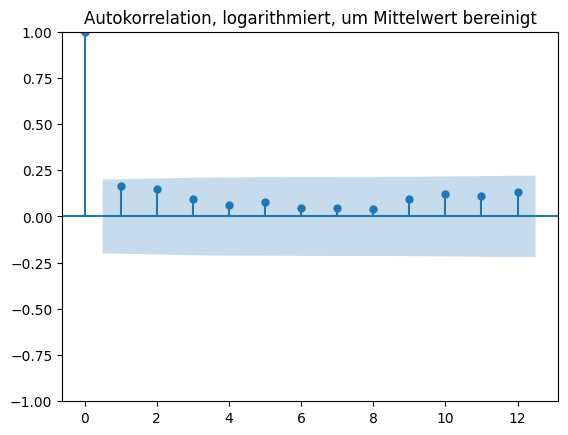

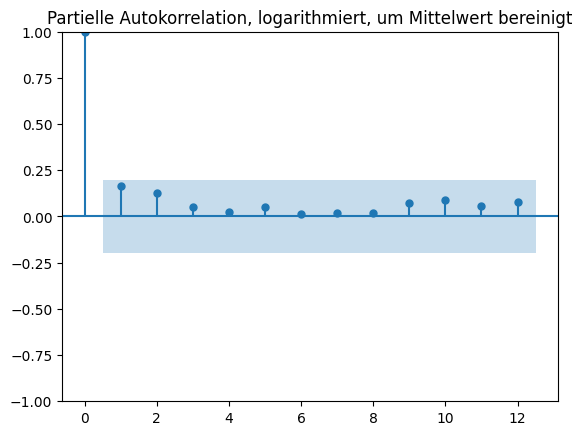

In [48]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

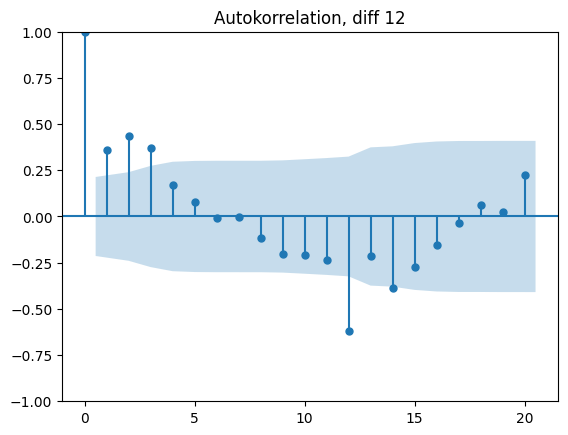

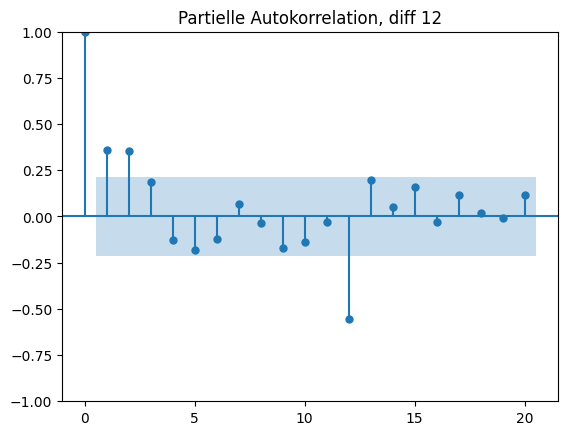

In [49]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [50]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -110.6641, AIC: 223.3282
ARIMA (0,1,0)x(0,1,0,12) LL -110.3137, AIC: 222.6274
ARIMA (1,0,0)x(0,1,1,12) LL -109.5661, AIC: 225.1322
ARIMA (1,0,0)x(0,1,2,12) LL -109.5454, AIC: 227.0908
ARIMA (1,1,0)x(0,1,2,12) LL -104.9732, AIC: 217.9463
ARIMA (0,0,1)x(0,1,2,12) LL -109.7276, AIC: 227.4553
ARIMA (0,1,1)x(0,1,2,12) LL -107.1987, AIC: 220.3974
ARIMA (0,1,1)x(2,1,0,12) LL -107.0647, AIC: 222.1293


In [51]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(0, 1, 1)x(0, 1, [2], 12)   Log Likelihood                -107.199
Date:                              Sun, 09 Feb 2025   AIC                            220.397
Time:                                      22:47:03   BIC                            227.310
Sample:                                  01-01-2016   HQIC                           223.155
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5386      0.066     -8.142      0.000      -0.668      -0.409
ma.S.L24       0.01

In [52]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean      unlogged   new_predict
2023-04-01       10.442177  34275.199758  37796.554702
2023-05-01       10.882689  53246.602410  54731.205849
2023-06-01       10.816444  49833.565975  51684.589717
2023-07-01       10.872437  52703.508074  54246.417597
2023-08-01       11.065582  63932.416733  64269.801444
2023-09-01       10.592445  39832.758576  42757.459361
2023-10-01       10.479095  35564.210702  38947.178674
2023-11-01       10.220639  27464.205349  31716.782089
2023-12-01        9.301272  10951.940855  16977.258398
2024-01-01        9.970484  21385.836058  26290.980668
2024-02-01       10.081242  23890.647752  28526.878192
2024-03-01       10.348791  31219.285218  35068.720202
2024-04-01       10.394443  32677.520666  36370.400898
2024-05-01       10.840742  51059.242743  52778.679007
2024-06-01       10.771203  47629.259091  49716.935095
2024-07-01       10.830242  50525.952516  52302.642306
2024-08-01       11.024886  61382.876791  61993.977653
2024-09-01

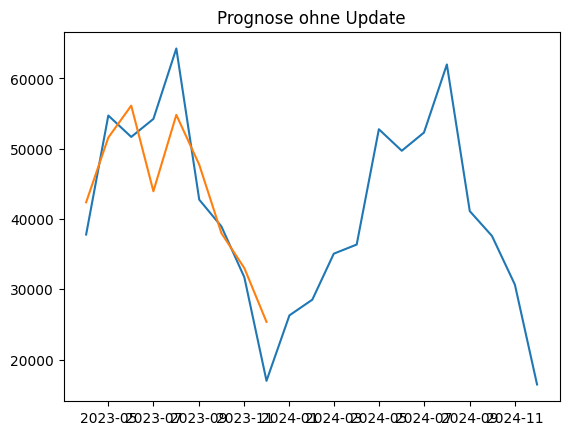

mean absolute error (mae): ARIMA: 5282.7733
mean squared error (mse): ARIMA: 38185421.2701
mean absolute percentage error (mape): ARIMA: 0.1283


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\1074150843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_15512\1074150843.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykern

In [53]:
plt.plot(y_pred_no_update['new_predict'])
plt.plot(df_test_seas[header])

plt.title('Prognose ohne Update')
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [54]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.442177,34275.199758,37796.554702
2023-05-01,10.947183,56793.813952,57897.592178
2023-06-01,10.819679,49995.044441,51828.732010
2023-07-01,10.918188,55170.760741,56448.788396
2023-08-01,10.976257,58469.294589,59393.194829
2023-09-01,10.460825,34920.344353,38372.437196
2023-10-01,10.468645,35194.485969,38617.147232
2023-11-01,10.200869,26926.566647,31236.863761
2023-12-01,9.314560,11098.442154,17108.031459
2024-01-01,10.263447,28665.426847,32789.041605


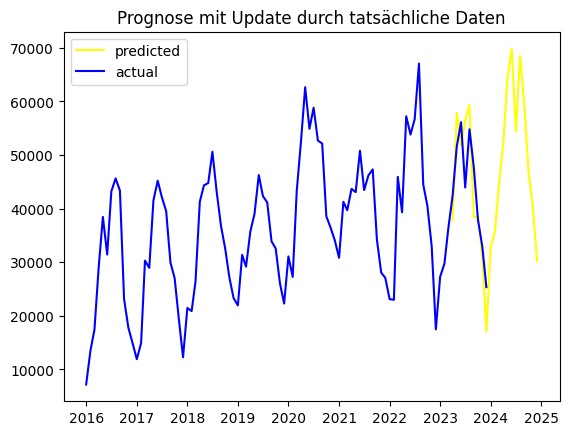

In [55]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2016-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [56]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 5810.7893
mean squared error (mse): ARIMA: 46197188.0830
mean absolute percentage error (mape): ARIMA: 0.1408
